# Expected (Noisy Runs) vs Observed (Real vs Noisy TVD)

This notebook generates `slot/4.png` using:
- **Expected**: repeated local noisy runs via `QuantumExecutor` (`noisy_simulator` vs `ideal_simulator`)
- **Observed**: existing real-vs-noisy TVD from `artifacts/grover3-3/tvd_summary.csv`

It also saves trial-level data to `slot/4_noisy_trials.csv`.


In [25]:
from __future__ import annotations

import csv
import json
import re
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qiskit import QuantumCircuit
from quantum.quantum_executor import QuantumExecutor
from quantum.metrics import calculate_tvd

ARTIFACT_DIR = REPO_ROOT / 'artifacts' / 'grover3-3'
OUT_PNG = REPO_ROOT / 'slot' / '4.png'
OUT_CSV = REPO_ROOT / 'slot' / '4_noisy_trials.csv'
CONFIG_FILE = REPO_ROOT / 'quantum_config.json'

SHOTS = 1024
TRIALS = 1

print('artifact:', ARTIFACT_DIR)
print('output image:', OUT_PNG)
print('output csv:', OUT_CSV)
print('config:', CONFIG_FILE)


artifact: /Users/qzydustin/WorkSpace/quantum/artifacts/grover3-3
output image: /Users/qzydustin/WorkSpace/quantum/slot/4.png
output csv: /Users/qzydustin/WorkSpace/quantum/slot/4_noisy_trials.csv
config: /Users/qzydustin/WorkSpace/quantum/quantum_config.json


In [26]:
def parse_top_row_from_tvd_summary(tvd_csv: Path) -> dict:
    rows = list(csv.DictReader(tvd_csv.open('r', encoding='utf-8')))
    if not rows:
        raise RuntimeError(f'Empty tvd_summary: {tvd_csv}')
    return max(rows, key=lambda r: float(r['tvd_loss']))


def build_single_qubit_sequence_circuit(sequence_full: str):
    parts = [s.strip() for s in sequence_full.split('→') if s.strip()]
    ops = []
    qubits = []
    for seg in parts:
        m = re.match(r'([a-zA-Z_][a-zA-Z0-9_]*)\((\d+)(?:,\s*([-+]?\d*\.?\d+))?\)', seg)
        if not m:
            continue
        name = m.group(1)
        q = int(m.group(2))
        p = float(m.group(3)) if m.group(3) is not None else None
        ops.append((name, q, p))
        if q not in qubits:
            qubits.append(q)

    if not ops:
        raise RuntimeError(f'Cannot parse sequence: {sequence_full}')

    qc = QuantumCircuit(1, 1)
    for name, _, p in ops:
        if name == 'rz':
            qc.rz(0.0 if p is None else p, 0)
        elif name == 'sx':
            qc.sx(0)
        elif name == 'x':
            qc.x(0)
        else:
            raise RuntimeError(f'Unsupported op for this notebook: {name}')
    qc.measure(0, 0)
    return qc, qubits, len(ops)


def run_expected_from_noisy_runs(qe: QuantumExecutor, qc: QuantumCircuit, shots: int, trials: int):
    trial_rows = []
    vals = []
    for i in range(1, trials + 1):
        ideal = qe.run_circuit(qc, execution_type='ideal_simulator', shots=shots)
        noisy = qe.run_circuit(qc, execution_type='noisy_simulator', shots=shots)
        tvd, _ = calculate_tvd(noisy.get('counts', {}), ideal.get('counts', {}))
        vals.append(float(tvd))
        trial_rows.append({
            'trial': i,
            'shots': shots,
            'expected_noisy_tvd': float(tvd),
            'ideal_counts': json.dumps(ideal.get('counts', {}), ensure_ascii=False),
            'noisy_counts': json.dumps(noisy.get('counts', {}), ensure_ascii=False),
        })
    mean_v = statistics.fmean(vals)
    return mean_v, trial_rows


def save_trials_csv(rows, out_csv: Path):
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    fields = ['trial', 'shots', 'expected_noisy_tvd', 'ideal_counts', 'noisy_counts']
    with out_csv.open('w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fields)
        w.writeheader()
        for r in rows:
            w.writerow(r)


qiskit_runtime_service._discover_account:WARNING:2026-02-17 15:21:59,832: Loading account with the given token. A saved account will not be used.


selected circuit: seq_003.qpy
selected sequence: rz(107, -2.7489) → sx(107)
observed(real-vs-noisy TVD): 0.0673828125
constructed local circuit gates: 2
target qubits in original sequence: [107]


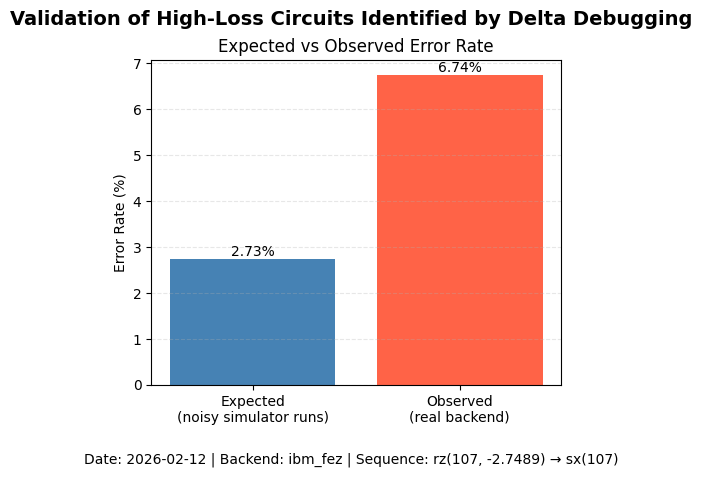

saved image: /Users/qzydustin/WorkSpace/quantum/slot/4.png
saved trials: /Users/qzydustin/WorkSpace/quantum/slot/4_noisy_trials.csv
expected mean: 0.02734375
observed     : 0.0673828125
deviation x  : 2.4642857142857144


In [27]:
top = parse_top_row_from_tvd_summary(ARTIFACT_DIR / 'tvd_summary.csv')
sequence = top['sequence_full']
observed = float(top['tvd_loss'])
circuit_name = top['circuit']

qc, qubits, n_gates = build_single_qubit_sequence_circuit(sequence)

print('selected circuit:', circuit_name)
print('selected sequence:', sequence)
print('observed(real-vs-noisy TVD):', observed)
print('constructed local circuit gates:', n_gates)
print('target qubits in original sequence:', qubits)

qe = QuantumExecutor(config_file=str(CONFIG_FILE))
expected_mean, trial_rows = run_expected_from_noisy_runs(qe, qc, shots=SHOTS, trials=TRIALS)
save_trials_csv(trial_rows, OUT_CSV)

deviation = observed / expected_mean if expected_mean > 0 else float('inf')

latest_report = sorted(ARTIFACT_DIR.glob('delta_debug_report_*.json'))[-1]
m = re.search(r'(\d{8})_(\d{6})', latest_report.name)
date_str = f"{m.group(1)[0:4]}-{m.group(1)[4:6]}-{m.group(1)[6:8]}" if m else 'N/A'

fig = plt.figure(figsize=(5, 5))
ax = fig.add_axes([0.10, 0.23, 0.82, 0.65])
vals_pct = [expected_mean * 100, observed * 100]
bars = ax.bar(
    ['Expected\n(noisy simulator runs)', 'Observed\n(real backend)'],
    vals_pct,
    color=['steelblue', 'tomato'],
)
ax.set_ylabel('Error Rate (%)')
ax.set_title('Expected vs Observed Error Rate')
ax.grid(axis='y', linestyle='--', alpha=0.3)
for b, v in zip(bars, vals_pct):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{v:.2f}%', ha='center', va='bottom', fontsize=10)

fig.suptitle('Validation of High-Loss Circuits Identified by Delta Debugging', fontsize=14, fontweight='bold')
caption = f'Date: {date_str} | Backend: ibm_fez | Sequence: {sequence}'
fig.text(0.5, 0.08, caption, ha='center', va='center', fontsize=10)

OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PNG, dpi=180)
plt.show()

print('saved image:', OUT_PNG)
print('saved trials:', OUT_CSV)
print('expected mean:', expected_mean)
print('observed     :', observed)
print('deviation x  :', deviation)
